# Goal of this notebook - 
Compare:

Random Forest (Baseline)
vs
XGBoost (Advanced)

and determine:

* Accuracy
* F1 Score
* Precision
* Recall

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

from xgboost import XGBClassifier

## Load Engineered Dataset

In [2]:
DATA_PATH = Path(
    "../data/processed/pairwise_engineered.csv"
)

df = pd.read_csv(DATA_PATH)

print(df.shape)

(10000, 150)


## Create Balanced Labels

In [4]:
def classify_compatibility(score):

    if score < 71.48:
        return "Low"

    elif score < 77.78:
        return "Medium"

    else:
        return "High"

df["compatibility_label"] = (df["compatibility_score"].apply(classify_compatibility))

df["compatibility_label"].value_counts()

compatibility_label
High      3409
Medium    3299
Low       3292
Name: count, dtype: int64

## One-Hot Encode

In [5]:
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

categorical_columns.remove(
    "compatibility_label"
)

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=False
)

## Feature and  Target

In [7]:
X = df.drop(
    columns=[
        "compatibility_score",
        "compatibility_label"
    ]
)

y = df["compatibility_label"]

print(X.shape)

(10000, 207)


## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #keeps class balance in train and test sets
)

## Random Forest Baseline

In [16]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)
rf_predictions = rf.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print("Model Training Completed")
print("RF Accuracy:", rf_accuracy)
print("RF F1:", rf_f1)

Model Training Completed
RF Accuracy: 0.7785
RF F1: 0.7765068002585649


In [20]:
print(df.shape)
print(X.shape)
print(X_train.shape)

(10000, 209)
(10000, 207)
(8000, 207)


In [21]:
import xgboost

print(xgboost.__version__)

3.2.0


XGBoost does NOT accept:

High
Medium
Low

It needs integers.

In [22]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['High' 'Low' 'Medium']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [24]:
xgb_model = XGBClassifier(

    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

In [25]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegresso

In [26]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [27]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="weighted"
)

print(
    "XGB Accuracy:",
    round(xgb_accuracy, 4)
)

print(
    "XGB F1:",
    round(xgb_f1, 4)
)

XGB Accuracy: 0.846
XGB F1: 0.8471


In [28]:
print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       682
           1       0.91      0.87      0.89       658
           2       0.75      0.80      0.77       660

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [29]:
# Comparison Table
comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        xgb_accuracy
    ],

    "F1 Score": [
        rf_f1,
        xgb_f1
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Random Forest,0.7785,0.776507
1,XGBoost,0.8460,0.847083


## Feature Importance

In [30]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
132,behavioral_alignment_score,0.029874
131,same_lifestyle_type,0.024577
129,social_compatibility,0.023397
115,noise_sleep_tolerance_diff,0.022850
106,sleep_time_diff,0.021612
125,noise_sleep_tolerance_similarity,0.021146
116,sleep_time_similarity,0.018691
109,cleanliness_score_diff,0.015321
119,cleanliness_score_similarity,0.011926
95,schedule_consistency_2,0.011559


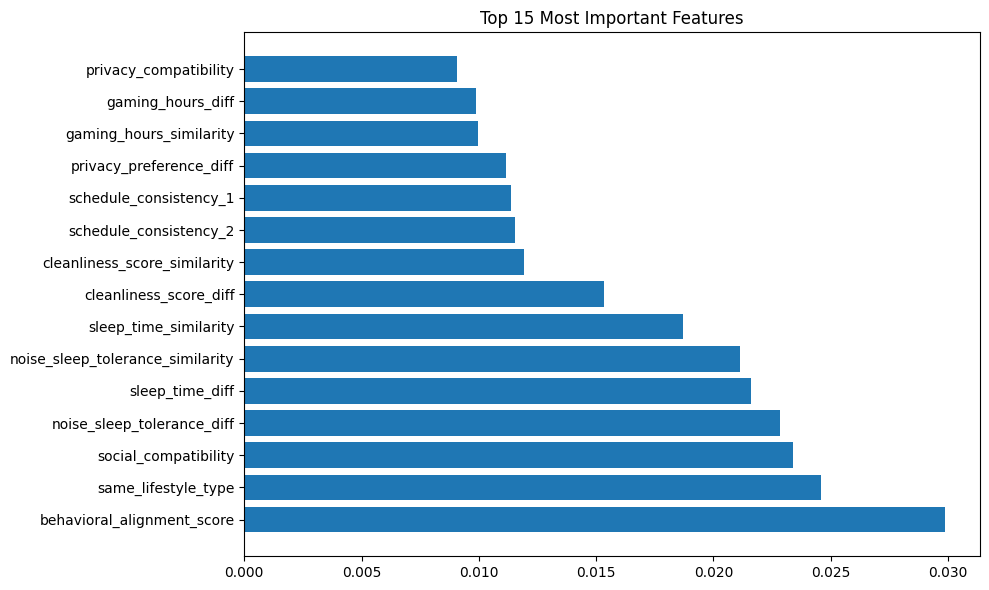

In [31]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Most Important Features"
)

plt.tight_layout()

plt.show()

Feature importance analysis revealed that behavioral alignment, lifestyle similarity, sleep schedules, cleanliness preferences, privacy expectations, and social habits were the strongest predictors of roommate compatibility, outperforming demographic attributes.